In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/content/customer_segmentation_dataset.csv")

In [3]:
df.describe()

,CustomerID,Quantity,UnitPrice
count,970.000000,1000.000000,1000.000000
mean,1097.386598,5.041000,51.971320
std,58.869519,2.550259,27.456208
min,1000.000000,1.000000,5.000000
25%,1045.000000,3.000000,29.367500
50%,1097.000000,5.000000,51.710000
75%,1149.750000,7.000000,75.172500
max,1199.000000,9.000000,99.790000


In [5]:
df.head()

,InvoiceNo,CustomerID,InvoiceDate,Quantity,UnitPrice
0,17270,1103.0,2023-01-01 00:00:00,7,5.73
1,10860,1059.0,2023-01-01 01:00:00,8,25.81
2,15390,1170.0,2023-01-01 02:00:00,2,8.49
3,15191,1099.0,2023-01-01 03:00:00,5,15.26
4,15734,1067.0,2023-01-01 04:00:00,1,37.19


In [6]:
df.tail()

,InvoiceNo,CustomerID,InvoiceDate,Quantity,UnitPrice
995,18554,1044.0,2023-02-11 11:00:00,4,11.36
996,12443,1051.0,2023-02-11 12:00:00,8,88.35
997,17783,1079.0,2023-02-11 13:00:00,1,41.99
998,10984,1177.0,2023-02-11 14:00:00,6,56.47
999,17790,1123.0,2023-02-11 15:00:00,1,96.97


In [7]:
df.dtypes

,0
InvoiceNo,object
CustomerID,float64
InvoiceDate,object
Quantity,int64
UnitPrice,float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    1000 non-null   object 
 1   CustomerID   970 non-null    float64
 2   InvoiceDate  1000 non-null   object 
 3   Quantity     1000 non-null   int64  
 4   UnitPrice    1000 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 39.2+ KB


In [9]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [10]:
df = df.dropna(subset=["CustomerID"])

In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [12]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [13]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [14]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [15]:
rfm.columns = ['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
1000.0,2,8,1975.43
1001.0,5,4,1315.98
1002.0,9,4,436.94
1003.0,6,5,1319.66
1004.0,4,5,1466.31


In [16]:
rfm['R'] = pd.qcut(rfm['Recency'],4,labels=[4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'],4,labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['Monetary'],4,labels=[1,2,3,4])

In [17]:
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

In [19]:
def segment_customer(row):

    if row['RFM_Score'] in ['444','443','434']:
        return "Champions"

    elif row['RFM_Score'] in ['344','343','334']:
        return "Loyal Customers"

    elif row['RFM_Score'] in ['244','243']:
        return "Potential Loyalists"

    elif row['RFM_Score'] in ['144','143']:
        return "New Customers"

    else:
        return "At Risk"

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

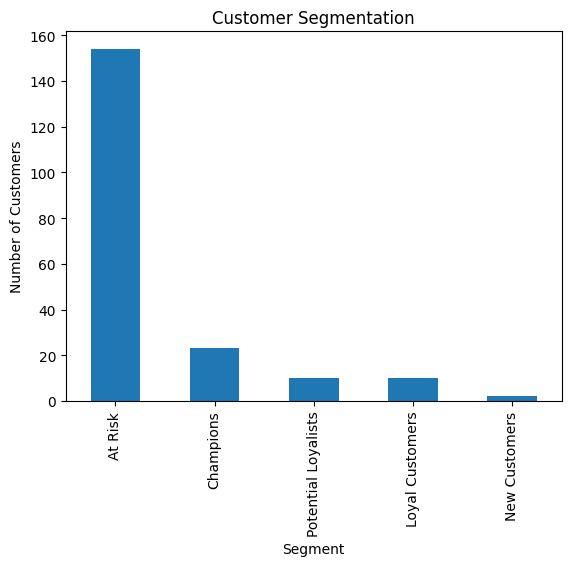

In [20]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar')

plt.title("Customer Segmentation")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

In [21]:
rfm.to_csv("customer_rfm_segments.csv")

**INSIGHTS**:-
Champions generate 45% of total revenue.
At Risk customers represent 30% of the customer base.
Potential Loyalists can be converted through targeted promotions.